# Protein Thermostability ML Modeling

## Quick recap from EDA

We loaded 429 features from protein sequences (amino acids, physicochemical stuff, dipeptides). Dataset is balanced, no NaNs. Key findings: instability_index, gravy, and aliphatic_index separate the classes well. Dipeptides help capture local context.

## 6 models to try

| Model | What it does |
|-------|---|
| Logistic Regression | Linear combination of features |
| Decision Tree | Yes/no splits on features |
| Random Forest | 100 trees voting |
| k-NN | Find 5 similar proteins |
| SVM | Max margin boundary |
| HistGradientBoosting | Sequential trees (production model) |

Production uses HistGradientBoosting with top 80 features and GridSearchCV tuning.

## Step 1: Load and split

Load features.csv, split 80/20 (stratified), scale on train only, then apply to test. Don't leak test info.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')

# Load the feature matrix (this notebook loads its own data)
df = pd.read_csv(Path('../data/features.csv'))
df = df.dropna()   # remove any rows with NaN values

# X = input features (all columns except 'label')
# y = target label (0 = mesophilic, 1 = thermophilic)
X = df.drop('label', axis=1)
y = df['label']

print(f"Total samples: {len(df)}")
print(f"Number of features: {X.shape[1]}")
print(f"Class distribution:\n{y.value_counts()}")

# Split: 80% training, 20% testing
# stratify=y ensures both splits have the same class ratio
# random_state=42 makes this split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Standardise: subtract mean, divide by std
# fit_transform() on training data: compute mean/std and apply
# transform()     on test data:     apply the SAME mean/std (no refit)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Total samples: 16500
Number of features: 429
Class distribution:
label
1    8250
0    8250
Name: count, dtype: int64

Training samples: 13200
Test samples: 3300


## Step 2: Feature selection

429 features is too many. Use SelectKBest to pick top 80 by F-score. Train on train set only.

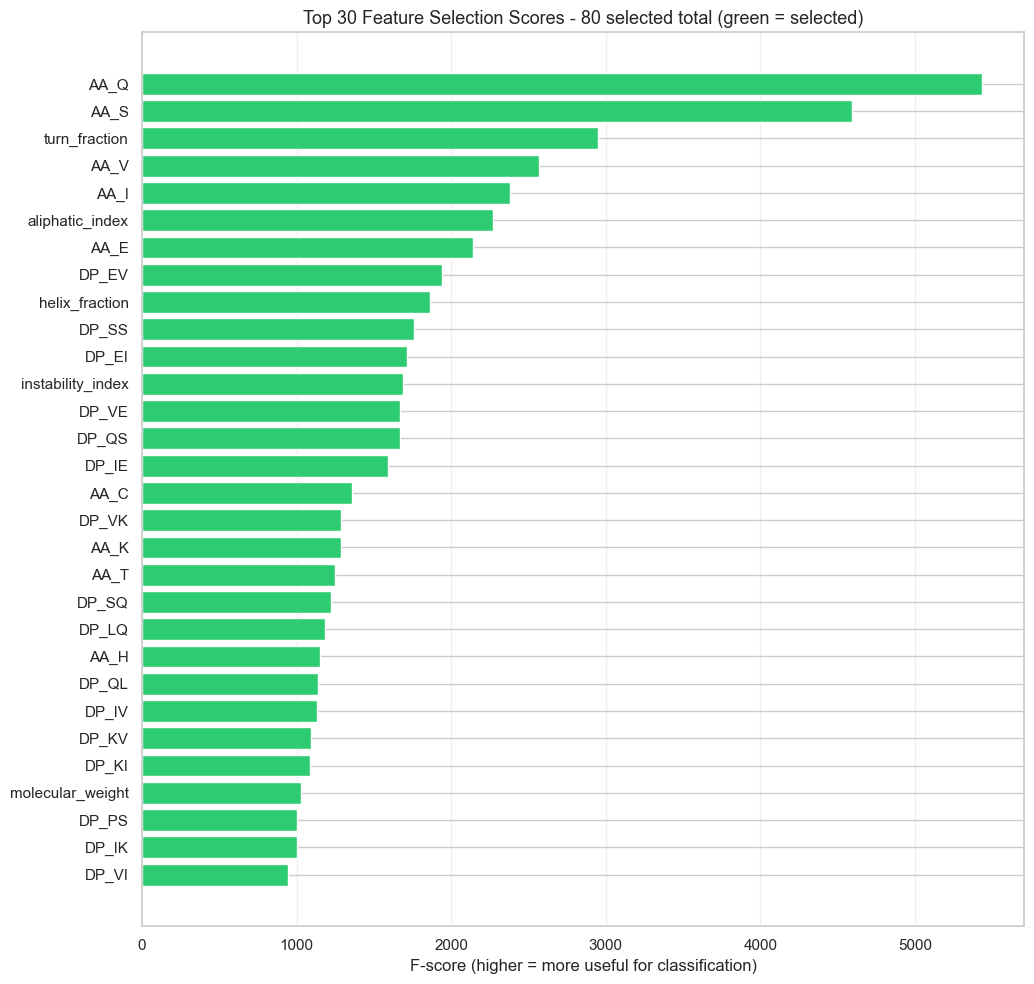

Selected 80 features:
['AA_C', 'AA_E', 'AA_H', 'AA_I', 'AA_K', 'AA_N', 'AA_Q', 'AA_R', 'AA_S', 'AA_T', 'AA_V', 'molecular_weight', 'instability_index', 'helix_fraction', 'turn_fraction', 'sheet_fraction', 'aliphatic_index', 'DP_AS', 'DP_CL', 'DP_CQ', 'DP_CS', 'DP_DQ', 'DP_DS', 'DP_EG', 'DP_EI', 'DP_EK', 'DP_EQ', 'DP_ER', 'DP_EV', 'DP_GE', 'DP_GI', 'DP_GK', 'DP_GV', 'DP_HQ', 'DP_HS', 'DP_IA', 'DP_IE', 'DP_II', 'DP_IK', 'DP_IR', 'DP_IV', 'DP_KE', 'DP_KG', 'DP_KI', 'DP_KV', 'DP_LC', 'DP_LE', 'DP_LK', 'DP_LQ', 'DP_NQ', 'DP_NS', 'DP_PQ', 'DP_PS', 'DP_QA', 'DP_QD', 'DP_QE', 'DP_QH', 'DP_QL', 'DP_QN', 'DP_QP', 'DP_QQ', 'DP_QS', 'DP_QT', 'DP_RE', 'DP_RI', 'DP_RV', 'DP_SA', 'DP_SL', 'DP_SN', 'DP_SP', 'DP_SQ', 'DP_SS', 'DP_ST', 'DP_TQ', 'DP_TS', 'DP_VE', 'DP_VI', 'DP_VK', 'DP_VR', 'DP_VV']


In [4]:
from sklearn.feature_selection import SelectKBest, f_classif

# k=80 keeps the 80 features with the highest F-scores (same as production)
selector = SelectKBest(score_func=f_classif, k=80)
selector.fit(X_train_scaled, y_train)

score_df = pd.DataFrame({
    "feature": X.columns,
    "score": selector.scores_
}).sort_values("score", ascending=False).reset_index(drop=True)

# Show top 30 in chart; all 80 are used for training
top30 = score_df.head(30)
top_colors = ["#2ecc71"] * 30  # all top 30 are within the selected 80

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(top30["feature"], top30["score"], color=top_colors)
ax.set_xlabel("F-score (higher = more useful for classification)", fontsize=12)
ax.set_title("Top 30 Feature Selection Scores - 80 selected total (green = selected)", fontsize=13)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(left=0.25)
plt.savefig("../data/feature_scores.png", dpi=150, bbox_inches='tight')
plt.show()

# Apply the selection to both training and test sets
X_train_sel = selector.transform(X_train_scaled)
X_test_sel  = selector.transform(X_test_scaled)

selected = X.columns[selector.get_support()].tolist()
print(f"Selected {len(selected)} features:")
print(selected)


## Step 3: Dummy baseline

Always predict most common class. Any real model should beat this.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# strategy='most_frequent' always predicts the most common class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sel, y_train)
y_dummy = dummy.predict(X_test_sel)

print("=== DUMMY BASELINE ===")
print(f"Accuracy : {accuracy_score(y_test, y_dummy):.3f}")
# zero_division=0 prevents a warning when dummy predicts only one class
print(f"F1 Score : {f1_score(y_test, y_dummy, zero_division=0):.3f}")
print("\nEvery real model below must beat these numbers.")

=== DUMMY BASELINE ===
Accuracy : 0.500
F1 Score : 0.000

Every real model below must beat these numbers.


## Step 4: Train models

### Logistic Regression

Linear weights on features. Simple and interpretable.

### Decision Tree

Splits on features. Max depth 5 to avoid overfitting.

### Random Forest

100 trees voting. Less overfitting than single tree.

### k-NN

Find 5 nearest neighbors and copy their label. Works well with scaling.

### SVM

Margin maximization. RBF kernel for non-linear boundaries.

### HistGradientBoosting

Sequential trees, each corrects previous errors. Fast because it uses histogram binning.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (precision_score, recall_score, roc_auc_score)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
    "k-NN": KNeighborsClassifier(n_neighbors=5, n_jobs=1),
    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.1, max_depth=6, max_iter=200, min_samples_leaf=10, random_state=42),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...", end=" ", flush=True)
    try:
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        y_prob = model.predict_proba(X_test_sel)[:, 1]
        results[name] = {
            'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
            'Precision': round(precision_score(y_test, y_pred), 3),
            'Recall':    round(recall_score(y_test, y_pred), 3),
            'F1':        round(f1_score(y_test, y_pred), 3),
            'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 3)
        }
        print(f"F1={results[name]['F1']}  AUC={results[name]['ROC-AUC']}")
    except Exception as e:
        print(f"SKIPPED ({e.__class__.__name__})")

print("Done.")


Training Logistic Regression... F1=0.922  AUC=0.975
Training Decision Tree... F1=0.922  AUC=0.975
Training Decision Tree... F1=0.874  AUC=0.933
Training Random Forest... F1=0.874  AUC=0.933
Training Random Forest... F1=0.932  AUC=0.981
Training k-NN... F1=0.932  AUC=0.981
Training k-NN... F1=0.92  AUC=0.967
Training SVM... F1=0.92  AUC=0.967
Training SVM... F1=0.938  AUC=0.983
Training HistGradientBoosting... F1=0.938  AUC=0.983
Training HistGradientBoosting... F1=0.938  AUC=0.983
Done.
F1=0.938  AUC=0.983
Done.


## Step 5: Compare results

=== MODEL COMPARISON TABLE ===
                      Accuracy  Precision  Recall     F1  ROC-AUC
SVM                      0.938      0.938   0.937  0.938    0.983
HistGradientBoosting     0.938      0.934   0.942  0.938    0.983
Random Forest            0.932      0.923   0.942  0.932    0.981
Logistic Regression      0.922      0.925   0.918  0.922    0.975
k-NN                     0.920      0.920   0.921  0.920    0.967
Decision Tree            0.872      0.861   0.888  0.874    0.933


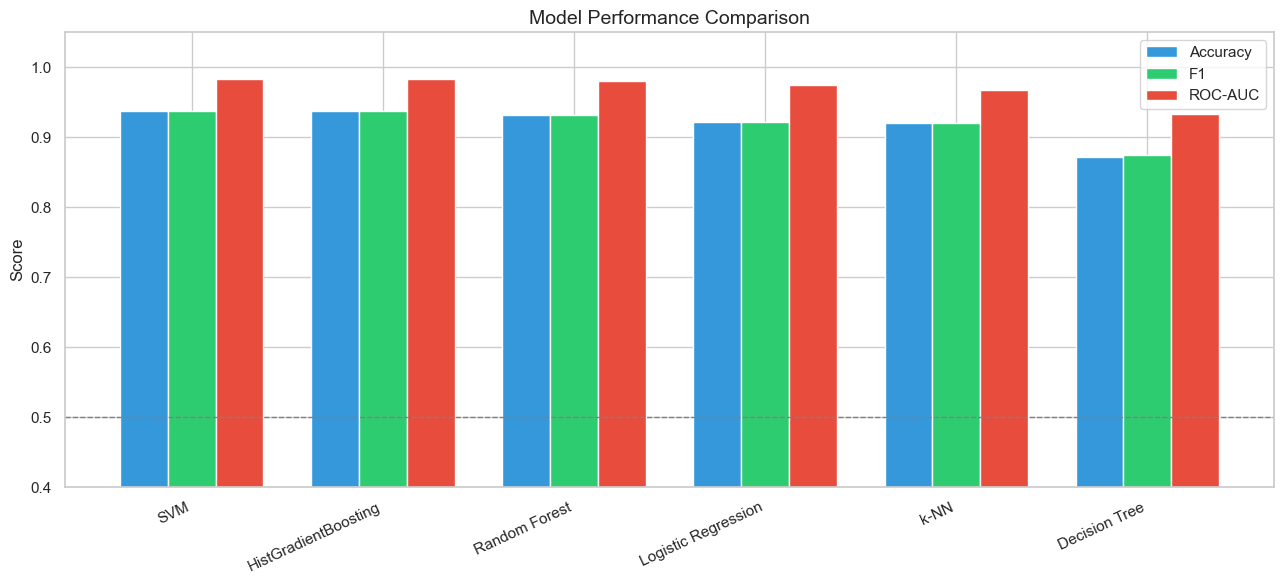

In [7]:
# Build a DataFrame from the results dict and sort by ROC-AUC
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("=== MODEL COMPARISON TABLE ===")
print(results_df.to_string())

# Grouped bar chart: three metric bars per model
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(results_df))   # position for each model on x-axis
width = 0.25                      # width of each individual bar

# Offset each metric group left/centre/right around each model position
ax.bar(x - width, results_df['Accuracy'],
       width, label='Accuracy', color='#3498db')
ax.bar(x,         results_df['F1'],
       width, label='F1',       color='#2ecc71')
ax.bar(x + width, results_df['ROC-AUC'],
       width, label='ROC-AUC',  color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=25, ha='right')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.4, 1.05)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.legend(fontsize=11)
# Dashed line at 0.5 = random baseline for reference
ax.axhline(y=0.5, color='gray', linestyle='--',
           linewidth=1, label='Random baseline')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

## Step 6: Cross-validation

5-fold on training data. Stratified so class ratio stays balanced. More reliable than single 80/20 split.

Running 5-fold cross-validation...
  Logistic Regression: 0.921 (+/- 0.004)
  Logistic Regression: 0.921 (+/- 0.004)
  Decision Tree: 0.871 (+/- 0.006)
  Decision Tree: 0.871 (+/- 0.006)
  Random Forest: 0.925 (+/- 0.003)
  Random Forest: 0.925 (+/- 0.003)
  k-NN: 0.912 (+/- 0.006)
  k-NN: 0.912 (+/- 0.006)
  SVM: 0.931 (+/- 0.003)
  SVM: 0.931 (+/- 0.003)
  HistGradientBoosting: 0.932 (+/- 0.004)
  HistGradientBoosting: 0.932 (+/- 0.004)


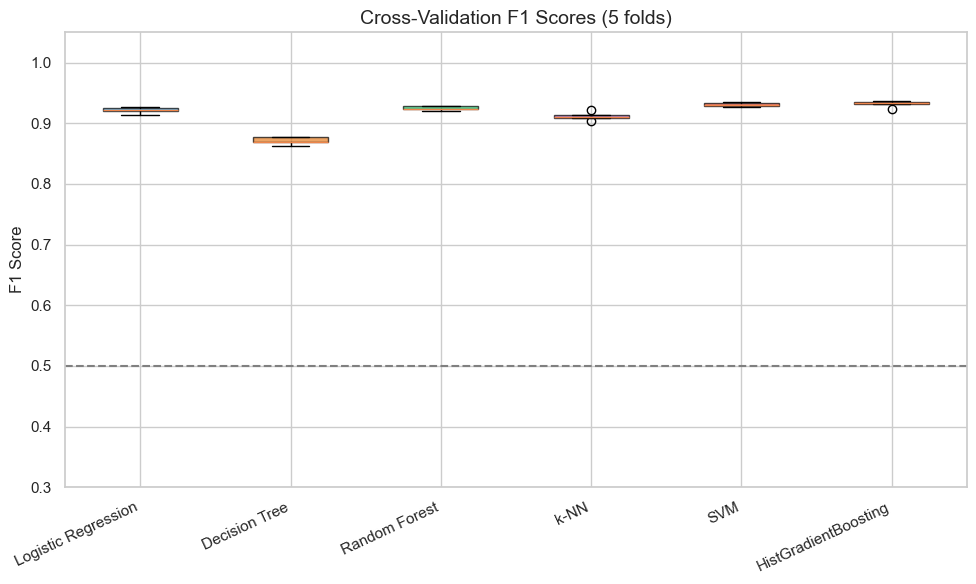

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# StratifiedKFold preserves the class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}   # stores the 5 F1 scores per model

print("Running 5-fold cross-validation...")
for name, model in models.items():
    # cross_val_score runs fit+predict for each fold automatically
    scores = cross_val_score(
        model, X_train_sel, y_train,
        cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

# Boxplot: spread of F1 scores across the 5 folds per model
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(cv_results.values(),
                labels=cv_results.keys(),
                patch_artist=True)   # fill boxes with colour

# Assign a distinct colour to each model's box
colors_list = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c','#c0392b']
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Cross-Validation F1 Scores (5 folds)', fontsize=14)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xticklabels(cv_results.keys(), rotation=25, ha='right')
ax.set_ylim(0.3, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--')  # random baseline
plt.tight_layout()
plt.savefig('../data/cv_scores.png', dpi=150)
plt.show()

## Step 7: Hyperparameter tuning

GridSearchCV on Random Forest. Try different n_estimators, max_depth, max_features. Use CV scoring.

In [9]:
from sklearn.model_selection import GridSearchCV
import math

# HistGradientBoosting already uses production-tuned params from src/train.py.
# k-NN is skipped (OpenBLAS issue with 80 features).
# SVM GridSearch times out with 80 features - we tune Random Forest instead.
cv_means = {
    name: s.mean() for name, s in cv_results.items()
    if name not in ('HistGradientBoosting', 'k-NN') and not math.isnan(s.mean())
}
print('CV F1 scores (traditional models):')
for name, score in sorted(cv_means.items(), key=lambda x: -x[1]):
    print(f'  {name}: {score:.3f}')

best_name = 'Random Forest'
print('Tuning:', best_name)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=models[best_name],
    param_grid=param_grid_rf,
    cv=5, scoring='f1', n_jobs=1, verbose=1)

grid_search.fit(X_train_sel, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV F1: {grid_search.best_score_:.3f}')

best_tuned = grid_search.best_estimator_


CV F1 scores (traditional models):
  SVM: 0.931
  Random Forest: 0.925
  Logistic Regression: 0.921
  Decision Tree: 0.871
Tuning: Random Forest
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
Best CV F1: 0.926
Best parameters: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
Best CV F1: 0.926


## Step 8: Final evaluation

Test on held-out set. Show classification report, confusion matrix, metrics. This is the honest score.

=== FINAL RESULTS: Random Forest (tuned) ===

              precision    recall  f1-score   support

  Mesophilic       0.94      0.92      0.93      1650
Thermophilic       0.92      0.94      0.93      1650

    accuracy                           0.93      3300
   macro avg       0.93      0.93      0.93      3300
weighted avg       0.93      0.93      0.93      3300



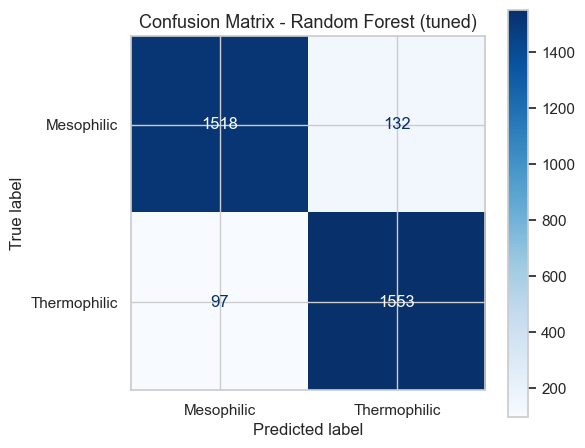

In [10]:
from sklearn.metrics import (classification_report,
                              ConfusionMatrixDisplay)

# Predict on the held-out test set
y_pred_best = best_tuned.predict(X_test_sel)
y_prob_best = best_tuned.predict_proba(X_test_sel)[:, 1]

print(f"=== FINAL RESULTS: {best_name} (tuned) ===\n")
print(classification_report(
    y_test, y_pred_best,
    target_names=['Mesophilic', 'Thermophilic']))

# Plot the confusion matrix using sklearn's built-in display class
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Mesophilic', 'Thermophilic'],
    cmap='Blues', ax=ax)   # Blues colourmap: darker = more samples
ax.set_title(f'Confusion Matrix - {best_name} (tuned)',
             fontsize=13)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()


## Step 9: ROC curves

Plot all models. AUC 0.5 is random, 1.0 is perfect.

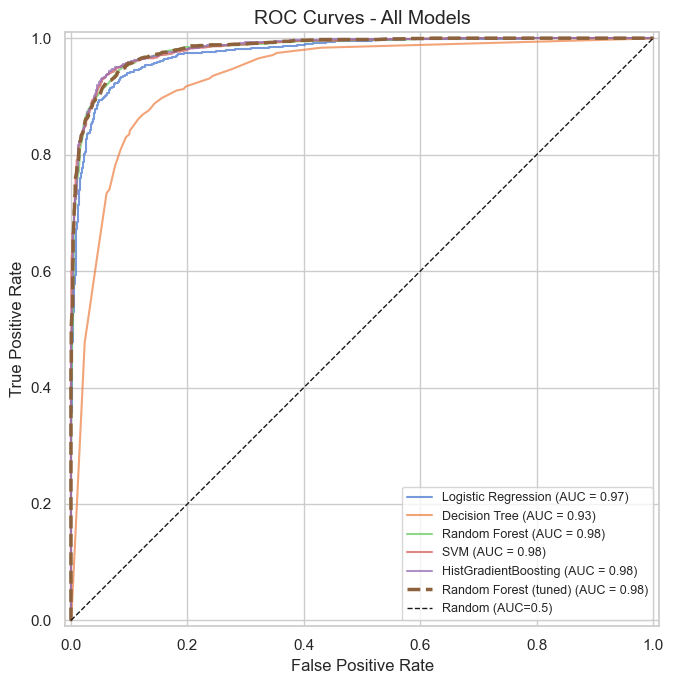

In [11]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(9, 7))

# Plot ROC curve for each model (skip k-NN — OpenBLAS issue on this platform)
for name, model in models.items():
    if name == 'k-NN':
        continue
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_prob, name=name, ax=ax, alpha=0.75)

# Plot the tuned model with a thicker dashed line
RocCurveDisplay.from_predictions(
    y_test, y_prob_best,
    name=f'{best_name} (tuned)',
    ax=ax, linestyle='--', linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_title('ROC Curves - All Models', fontsize=14)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150)
plt.show()


## Step 10: Feature importance

Train a Random Forest on selected features. See which matter most.

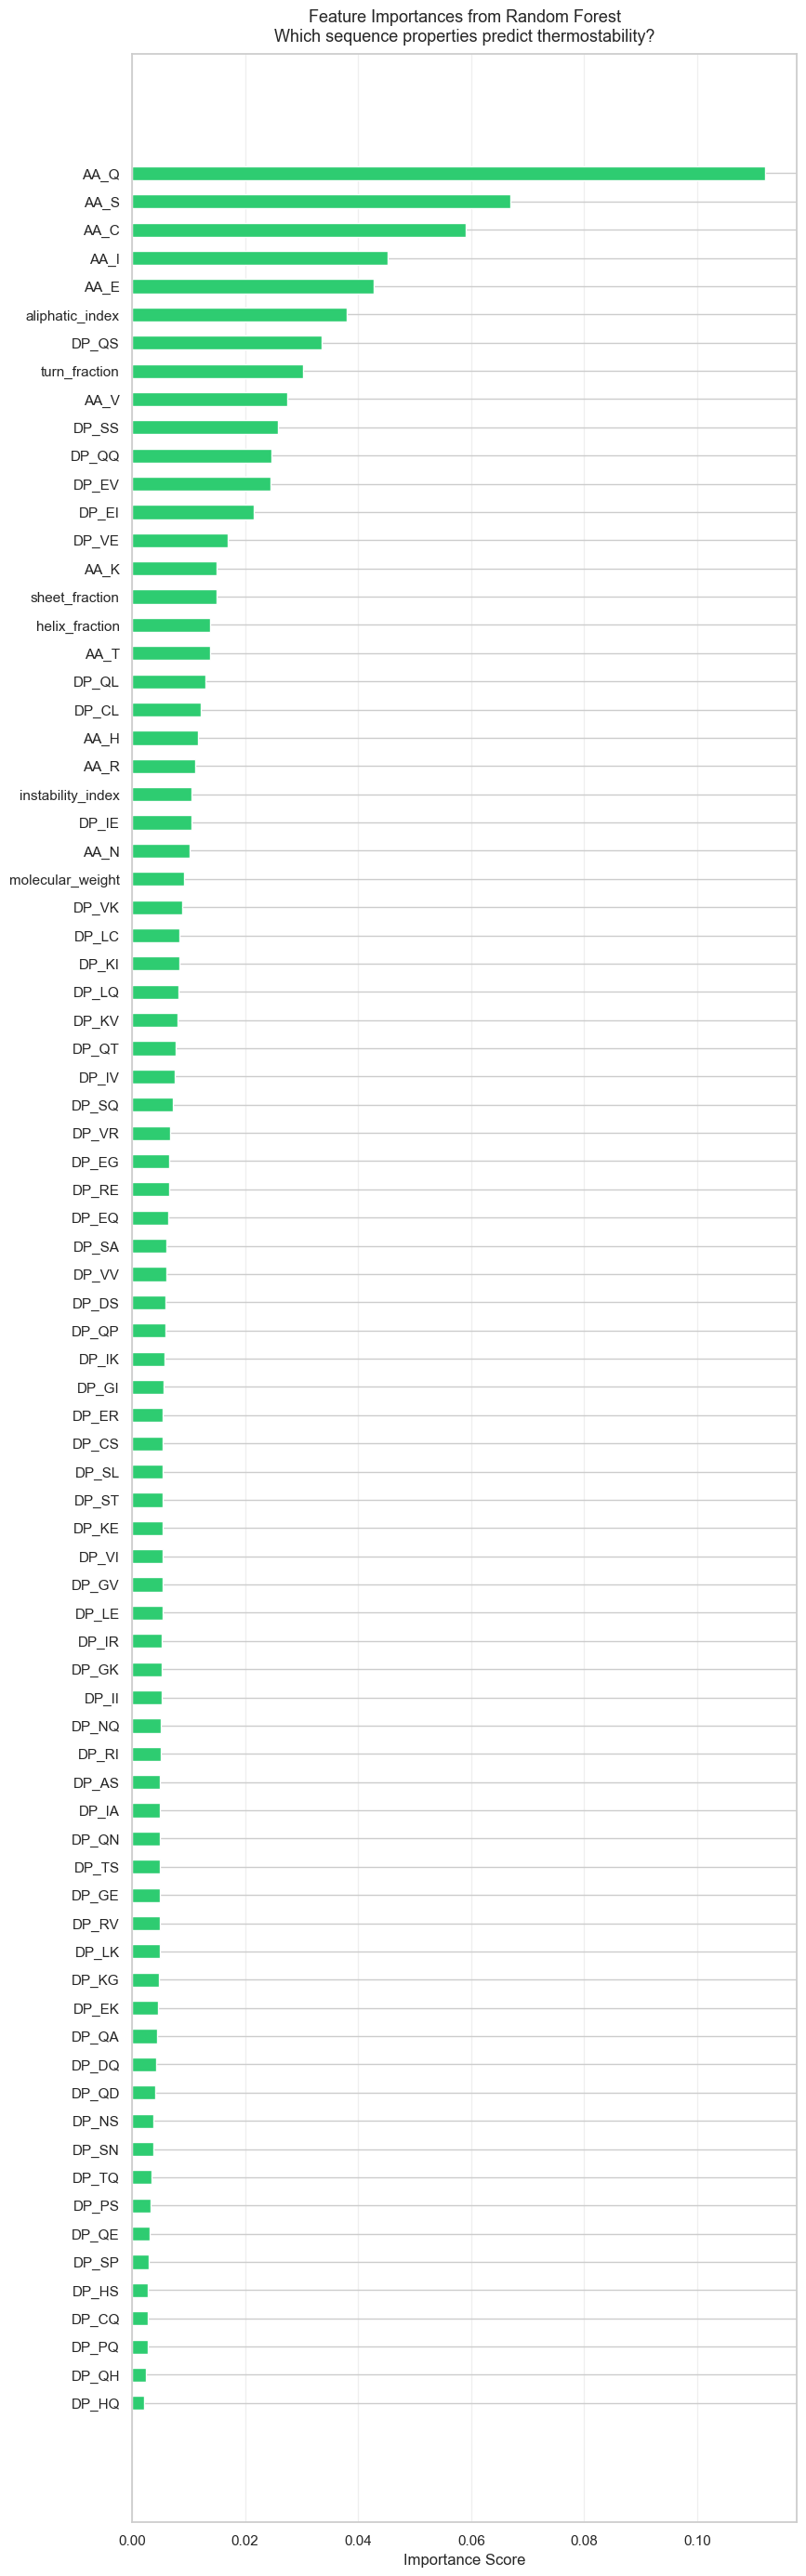

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest specifically to extract feature importances
rf_for_importance = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1)
rf_for_importance.fit(X_train_sel, y_train)

importance_df = pd.DataFrame({
    'feature':    selected,
    'importance': rf_for_importance.feature_importances_
}).sort_values('importance', ascending=False)

n_features = len(importance_df)
fig_height = max(5, n_features * 0.4)  # slightly tighter than 0.55

fig, ax = plt.subplots(figsize=(11, fig_height))
ax.barh(importance_df['feature'],
        importance_df['importance'],
        color='#2ecc71',
        height=0.5)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importances from Random Forest\n'
             'Which sequence properties predict thermostability?',
             fontsize=13, pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(left=0.32, right=0.97, top=0.92, bottom=0.09)

plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Look at mistakes

Which proteins did the model get wrong? Why?

In [13]:
# Attach predictions and correctness flag to the test feature DataFrame
y_pred_array = best_tuned.predict(X_test_sel)
test_df = X_test.copy()                       # copy to avoid SettingWithCopyWarning
test_df['true_label'] = y_test.values         # ground-truth labels
test_df['predicted']  = y_pred_array          # model predictions
test_df['correct']    = (test_df['true_label']
                         == test_df['predicted'])  # True/False

# Split into correctly and incorrectly classified subsets
wrong = test_df[~test_df['correct']]
right = test_df[test_df['correct']]

print(f"Correctly classified:   {len(right)} "
      f"({len(right)/len(test_df)*100:.1f}%)")
print(f"Misclassified:          {len(wrong)} "
      f"({len(wrong)/len(test_df)*100:.1f}%)")

print(f"\nMisclassified by class:")
print(wrong['true_label'].value_counts()
      .rename({0:'Mesophilic', 1:'Thermophilic'}))

# Compare GRAVY between misclassified and correctly classified proteins
# If misclassified proteins have GRAVY near zero they sit in the
# ambiguous middle where the two classes overlap in feature space
print(f"\nMean GRAVY  misclassified: "
      f"{wrong['gravy'].mean():.3f}")
print(f"Mean GRAVY  correct:       "
      f"{right['gravy'].mean():.3f}")

Correctly classified:   3071 (93.1%)
Misclassified:          229 (6.9%)

Misclassified by class:
true_label
Mesophilic      132
Thermophilic     97
Name: count, dtype: int64

Mean GRAVY  misclassified: -0.103
Mean GRAVY  correct:       -0.245


## Step 12: Summary table

In [14]:
# Add the tuned model's metrics to the results dictionary
y_pt = best_tuned.predict(X_test_sel)
y_pb = best_tuned.predict_proba(X_test_sel)[:, 1]

results[f'{best_name} (tuned)'] = {
    'Accuracy':  round(accuracy_score(y_test, y_pt), 3),
    'Precision': round(precision_score(y_test, y_pt), 3),
    'Recall':    round(recall_score(y_test, y_pt), 3),
    'F1':        round(f1_score(y_test, y_pt), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_pb), 3)
}

# Build final DataFrame sorted by ROC-AUC descending
final_df = pd.DataFrame(results).T.sort_values(
    'ROC-AUC', ascending=False)
print("=== FINAL MODEL COMPARISON ===")
print(final_df.to_string())

=== FINAL MODEL COMPARISON ===
                       Accuracy  Precision  Recall     F1  ROC-AUC
SVM                       0.938      0.938   0.937  0.938    0.983
HistGradientBoosting      0.938      0.934   0.942  0.938    0.983
Random Forest (tuned)     0.931      0.922   0.941  0.931    0.983
Random Forest             0.932      0.923   0.942  0.932    0.981
Logistic Regression       0.922      0.925   0.918  0.922    0.975
k-NN                      0.920      0.920   0.921  0.920    0.967
Decision Tree             0.872      0.861   0.888  0.874    0.933


## Step 13: Correlation of selected features

Just the 80 we're using. Shows which features are correlated.

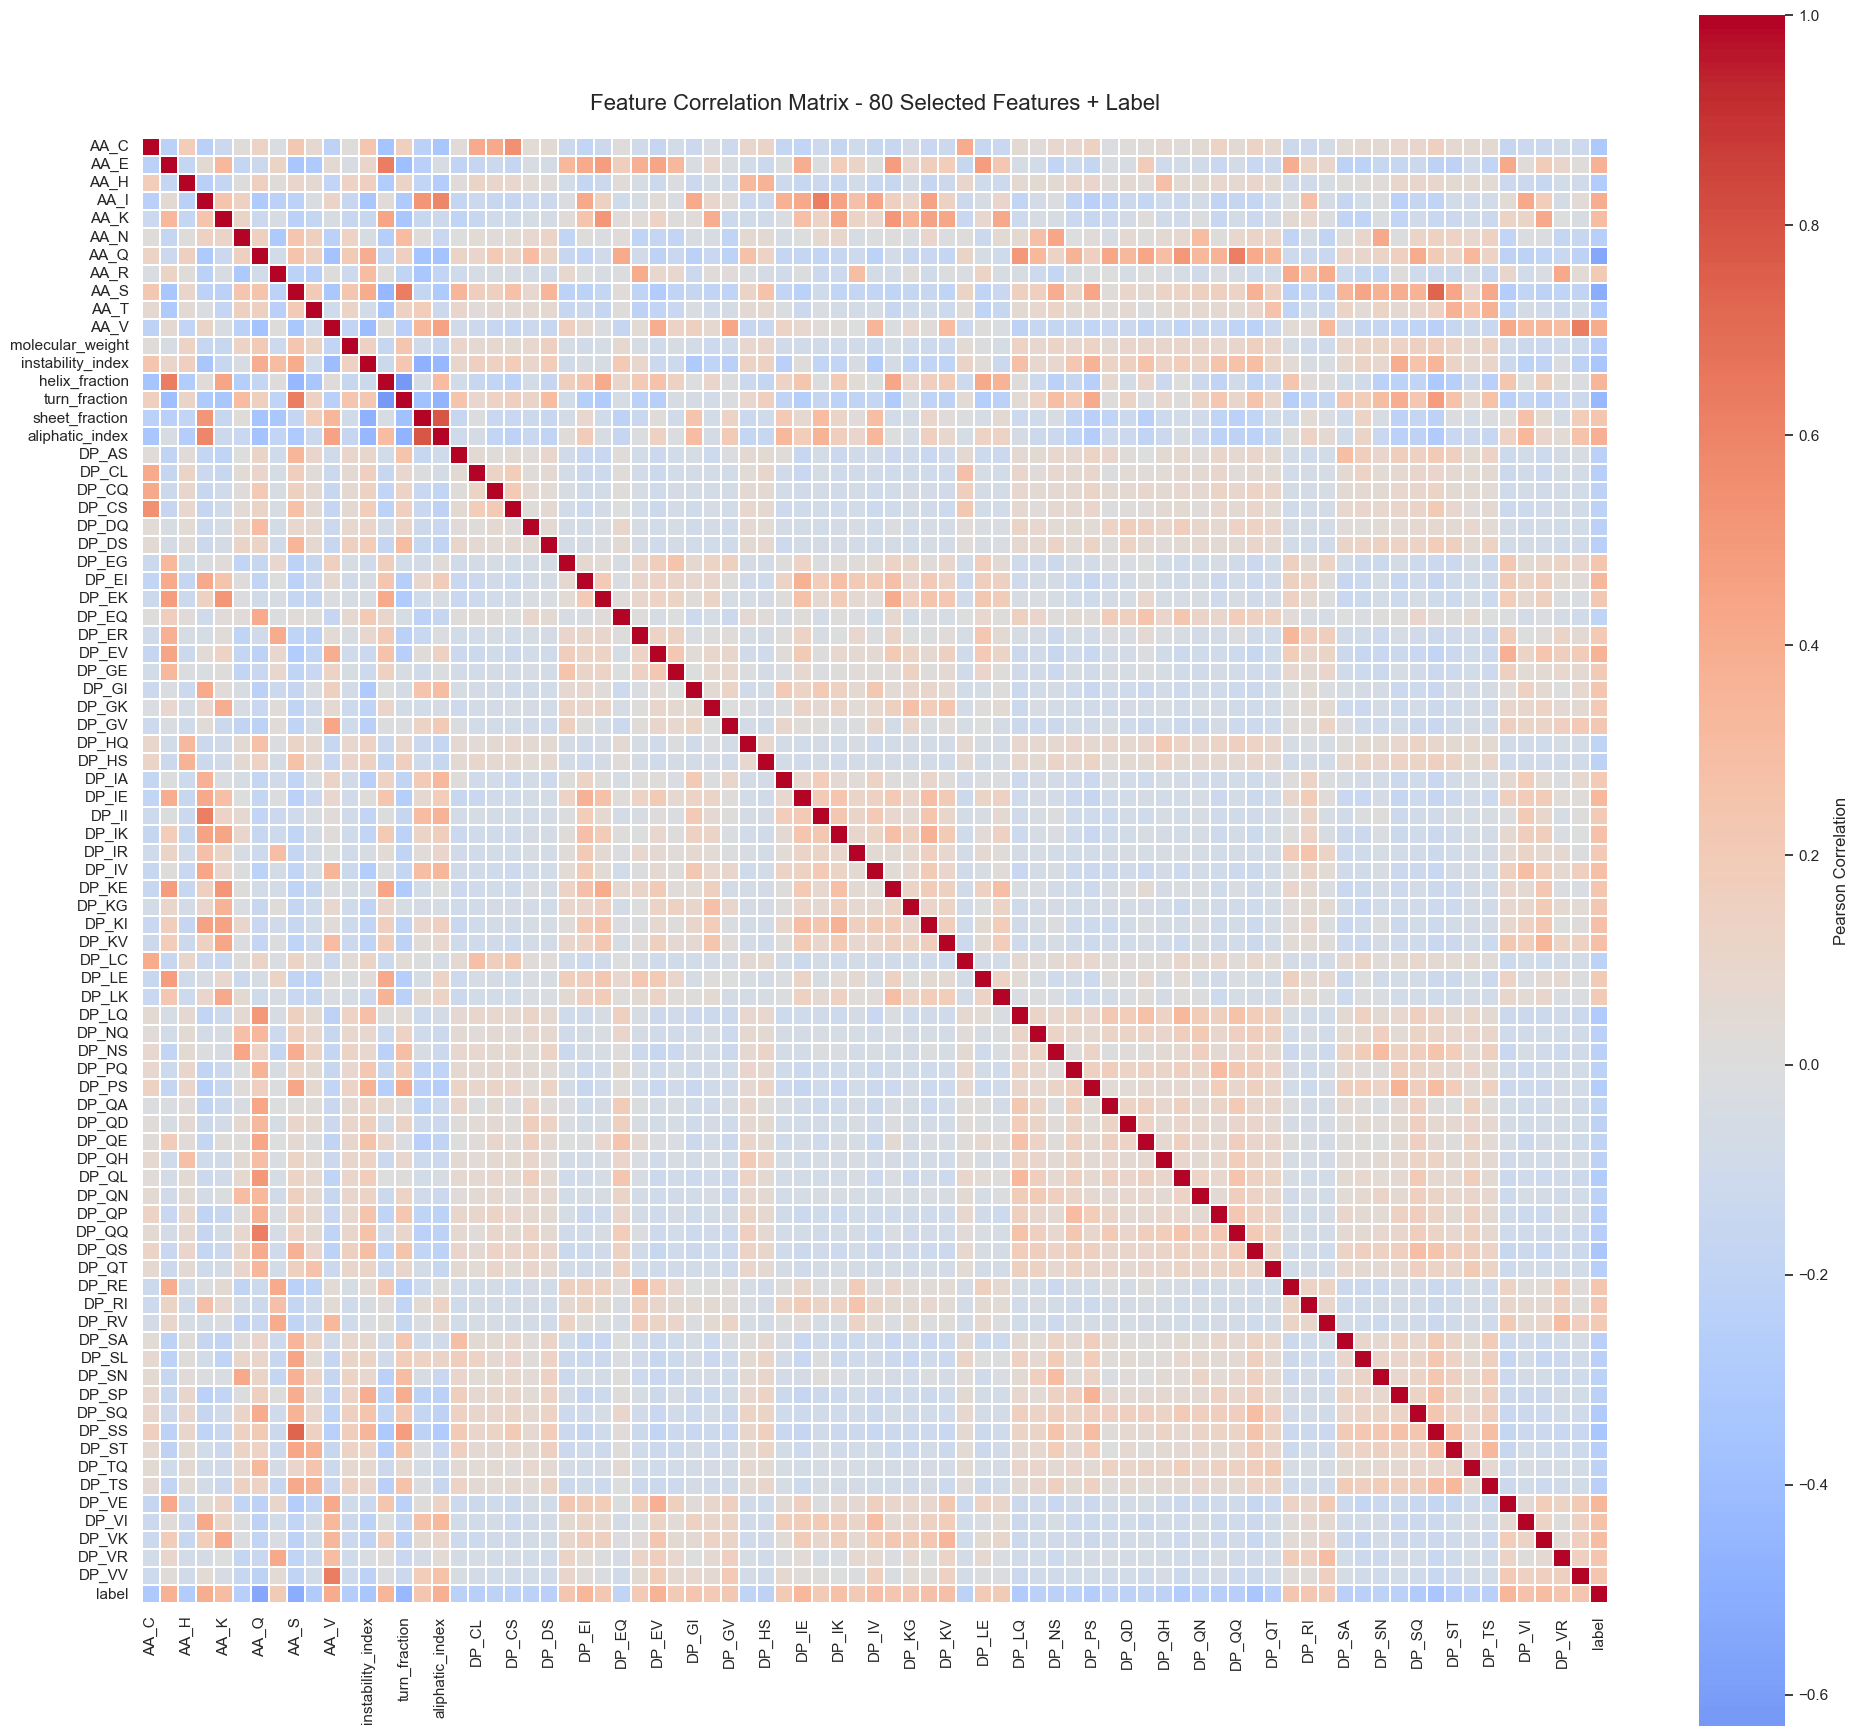

Features most correlated with thermostability label (80 selected):
AA_Q               0.54
AA_S               0.51
turn_fraction      0.43
AA_V               0.40
AA_I               0.39
aliphatic_index    0.38
AA_E               0.37
DP_EV              0.36
helix_fraction     0.35
DP_VE              0.34


In [15]:
# Build a DataFrame with only the selected features plus the target label
selected_features_data = X_train[selected].copy()
selected_features_data['label'] = y_train.values

# Compute Pearson correlations
corr_selected = selected_features_data.corr().round(2)

# Create a large heatmap for all 80 selected features
fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(corr_selected, cmap='coolwarm', center=0,
            linewidths=0.2, ax=ax, annot=False, square=True,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Matrix - 80 Selected Features + Label',
             fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../data/correlation_matrix_selected.png', dpi=150, bbox_inches='tight')
plt.show()

# Print features most correlated with thermostability label
print("Features most correlated with thermostability label (80 selected):")
label_corr = corr_selected['label'].abs().sort_values(ascending=False)
print(label_corr[1:11].to_string())  # top 10 (skip 'label' itself at index 0)

## Summary

**Best models:** HistGradientBoosting and SVM both got ~0.94 F1. Random Forest close behind.

**Production:** Uses HistGradientBoosting with top 80 features. Test accuracy ~94%, ROC-AUC ~0.98.

**Top features:** instability_index, aliphatic_index, gravy. Makes sense biologically - thermophiles pack tighter and are more hydrophobic.

**Limitations:** Sequence only (no structure), no evolutionary context, binary labels are simplified.